# Resnet-18 Training for Score Card Cell Recognition

The pretrained Resnet-18 from PyTorch is fine-tuned without freezing weights. The training strategy follows that of the scratch CNN but uses the AdamW optimizer instead. Training phases include the three datasets: synthetic dataset, mixed dataset, and real sample dataset.

Test dataset has been removed to include more samples in training but there are still some raw scorecards that are not involved in this training, they are used for production testing.

> Note: Train and validation loss and accuracy for the final phase stored in .pth files are wrong.

### v0 

Uses dataset creation setup of Scratch CNN v2.

| Phase | Epochs | Validation accuracy | lr | Weight decay | 
|----|----|----|----|----|
| 1 | 3 | 86.92% | 1e-4 | 1e-2 |
| 2 | 3 | 98.08% | 1e-4 | 1e-2 |
| 3 | 2 | 99.23% | 5e-5 | 5e-5 |

### v1 

Uses redefined dataset creation setup (still similar), but incorporates some cropped samples from test scorecards into validation set to check for consistency.

| Phase | Epochs | Validation accuracy | lr | Weight decay | 
|----|----|----|----|----|
| 1 | 3 | 84.37% | 1e-4 | 1e-2 |
| 2 | 5 | 97.55% | 5e-5 | 1e-2 |
| 3 | 5 | 98.12% | 2e-5 | 1e-2 |

Results: 
- 2.82% prediction error (2/71) on `"New/image_0.jpeg"` (1 was scribbled over).
- 0.00% prediction error (0/72) on `"New/image_1.jpeg"`.
- 0.00% prediction error (0/72) on `"New/image_2.jpeg"`.
- 1.39% prediction error (1/72) on `"New/image_3.jpeg"`.

In [16]:
import numpy as np
import cv2
import os, sys
from PIL import Image
import matplotlib.pyplot as plt
from skimage import io, filters, color
from pathlib import Path
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import train_test_split
import importlib
import seaborn as sns
from collections import defaultdict, Counter
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))
MODELS_DIR = PROJECT_ROOT / "models"
sys.path.insert(0, str(MODELS_DIR))
data_path = "..\\data\\Data2"
syndata_path = "..\\syn_cell_dataset"
weights_path = "..\\weights"

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from constants import BOLD_L, BOLD_R

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

NVIDIA GeForce RTX 2070 Super


In [55]:
import resnet18
importlib.reload(resnet18)
from resnet18 import RESNET18, ScorecardDataset

# 1. Define your standard transforms
real_transforms = T.Compose([
    T.Resize((64, 64)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
    T.RandomErasing(p=0.4, scale=(0.02, 0.08), ratio=(0.3, 3.0), value=0)
])
val_test_transforms = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(), 
    T.Normalize((0.5,), (0.5,))
])

syn_transform = T.Compose([T.Resize((64, 64)),              # Very slight rotation (upright cells)
                                    T.ColorJitter(brightness=0.1, contrast=0.1), # Simulate different pencil/ink/light
                                    T.ToTensor(), 
                                    T.Normalize((0.5,), (0.5,))]) # Centers data around 0 for faster convergence

# 2. Create Datasets
resnet_version = "resnet18_v1"
syn_dir = os.path.join(syndata_path, 'set2')
real_dir = os.path.join(data_path, 'Score')

syn_dataset = ScorecardDataset(data_dir=syn_dir, transform=syn_transform)
real_dataset = ScorecardDataset(data_dir=real_dir, transform=real_transforms)
val_dataset = ScorecardDataset(data_dir=real_dir, transform=val_test_transforms)

syn_ind = syn_dataset.df.index.tolist()
real_ind = real_dataset.df.index.tolist()

train_ind, val_ind = train_test_split(real_ind, test_size=0.3, random_state=42, stratify=real_dataset.df.iloc[real_ind]['label'])
mixtrain_idx, fine_idx = train_test_split(train_ind, test_size=0.5, random_state=42)

train_files = set(real_dataset.df.iloc[train_ind]['image'])
val_files   = set(real_dataset.df.iloc[val_ind]['image'])

mixtrain_files   = set(real_dataset.df.iloc[mixtrain_idx]['image'])
fine_files  = set(real_dataset.df.iloc[fine_idx]['image'])

# print(len(set(train_ind) & set(val_ind)))
# print(len(set(mixtrain_idx) & set(fine_idx)))
# print(real_dataset.df.iloc[val_ind]['label'].value_counts())

In [57]:
# -----------------------
# BALANCED MIX (key fix)
# -----------------------
# group indices by class
real_by_class = defaultdict(list)
for i in mixtrain_idx:
    lbl = int(real_dataset.df.loc[i,'label'])
    real_by_class[lbl].append(i)
# target = max real class count
max_count = max(len(v) for v in real_by_class.values())
mixsyn_idx = []
for c in range(10):  # for each class
    real_c = real_by_class[c]
    needed = max_count - len(real_c)
    df_c = syn_dataset.df[syn_dataset.df['label'] == c]
    if needed > 0 and len(df_c) > 0:
        sampled_df = df_c.sample(n=min(needed, len(df_c)), replace=False)
        mixsyn_idx.extend(sampled_df.index.tolist())
pretrain_syn_idx = list(set(syn_ind) - set(mixsyn_idx))
syn_subset = Subset(syn_dataset, pretrain_syn_idx)
mixed_subset = ConcatDataset([
    Subset(real_dataset, mixtrain_idx), 
    Subset(syn_dataset, mixsyn_idx)
])

# -------------------------------
# FINE-TUNE (real + blanks only)
# -------------------------------
syn_blank = syn_dataset.df[(syn_dataset.df['label'] == 0)].index.tolist()
blank_size = int(len(fine_idx) * 0.2)
_, syn_blank_fine = train_test_split(syn_blank, test_size=blank_size, random_state=42)
fine_subset = ConcatDataset([
    Subset(real_dataset, train_ind),
    Subset(syn_dataset, syn_blank_fine)
])

# --------------------------------
# Add test samples to val_loader
# --------------------------------
new_dir = os.path.join(data_path, 'New_Score')
new_dataset = ScorecardDataset(data_dir=new_dir, transform=val_test_transforms)
val_subset = ConcatDataset([
    Subset(val_dataset, val_ind),
    Subset(new_dataset, new_dataset.df.index.tolist())
])

# 3. Create DataLoaders
syn_loader = DataLoader(syn_subset, batch_size=64, shuffle=True)
mix_loader = DataLoader(mixed_subset, batch_size=32, shuffle=True)
train_loader = DataLoader(fine_subset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

In [59]:
def visualize_eval(loss, acc, cm):
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")
    plt.figure(figsize=(6,5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black')
    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('black')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

def see_distribution(title, dataset):
    counts = Counter()
    def process_subset(subset):
        labels = [subset.dataset.df.iloc[idx]['label'] for idx in subset.indices]
        counts.update(labels)
    if isinstance(dataset, Subset):
        process_subset(dataset)
    elif isinstance(dataset, ConcatDataset):
        for ds in dataset.datasets:
            process_subset(ds)
    dist = dict(counts)
    print(f"--- {BOLD_L}{title}{BOLD_R} Distribution (Total: {BOLD_L}{sum(counts.values())}{BOLD_R}) ---")
    for label in sorted(dist.keys()):
        percentage = (dist[label] / sum(counts.values())) * 100
        print(f"  Class {label}: {dist[label]:<6} samples ({percentage:.1f}%)")
    print()

see_distribution("SYN", syn_subset)
see_distribution("MIX", mixed_subset)
see_distribution("FINE-TUNE", fine_subset)
see_distribution("VAL", val_subset)

--- SYN Distribution (Total: 19033) ---
  Class 0: 2247   samples (11.8%)
  Class 1: 1994   samples (10.5%)
  Class 2: 2043   samples (10.7%)
  Class 3: 1936   samples (10.2%)
  Class 4: 1942   samples (10.2%)
  Class 5: 1664   samples (8.7%)
  Class 6: 1740   samples (9.1%)
  Class 7: 1932   samples (10.2%)
  Class 8: 1891   samples (9.9%)
  Class 9: 1644   samples (8.6%)

--- MIX Distribution (Total: 1420) ---
  Class 0: 142    samples (10.0%)
  Class 1: 142    samples (10.0%)
  Class 2: 142    samples (10.0%)
  Class 3: 142    samples (10.0%)
  Class 4: 142    samples (10.0%)
  Class 5: 142    samples (10.0%)
  Class 6: 142    samples (10.0%)
  Class 7: 142    samples (10.0%)
  Class 8: 142    samples (10.0%)
  Class 9: 142    samples (10.0%)

--- FINE-TUNE Distribution (Total: 997) ---
  Class 0: 103    samples (10.3%)
  Class 1: 1      samples (0.1%)
  Class 2: 3      samples (0.3%)
  Class 3: 68     samples (6.8%)
  Class 4: 179    samples (18.0%)
  Class 5: 267    samples (26.8%

In [12]:
from resnet18 import RESNET18
resnet = RESNET18(num_classes=10, lr=1e-3, weights=resnet18.ResNet18_Weights.DEFAULT)
cp_syn = torch.load(os.path.join(os.path.join(weights_path, resnet_version), "resnet_real_train_v2.pth"))
resnet.load_state_dict(cp_syn["model_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_19384\555635130.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, resn

<All keys matched successfully>

In [60]:
def show_predictions(model, dataloader, num_images=20):
    model.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(model.device)

            probs, logits = model(images)
            preds = torch.argmax(logits, dim=1)

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(len(images)):
                if num_images > 0 and shown >= num_images:
                    return

                img = images[i].squeeze().numpy()

                plt.figure(figsize=(3, 3))
                plt.imshow(img, cmap="gray")

                plt.title(
                    f"GT: {labels[i].item()} | Pred: {preds[i].item()}"
                )

                plt.axis("off")
                plt.show()

                shown += 1

In [46]:
show_predictions(resnet, val_loader, num_images=len(val_loader.dataset))

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>

In [62]:
import resnet18, focal_loss
importlib.reload(resnet18)
importlib.reload(focal_loss)
from resnet18 import RESNET18
from focal_loss import FocalLoss

resnet = RESNET18(num_classes=10, lr=1e-3, weights=resnet18.ResNet18_Weights.DEFAULT)
resnet.optimizer = torch.optim.AdamW(resnet.parameters(), lr=1e-4, weight_decay=1e-2)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     resnet.optimizer, T_max=10, eta_min=1e-5
# )
hist_syn = resnet.train_loop(syn_loader, val_loader, epochs=3)

Epoch 1/3: 100%|██████████| 298/298 [00:58<00:00,  5.06it/s, loss=0.0999]


Train Loss: 0.4001 | Train Acc: 87.26% | Val Loss: 0.6383 | Val Acc: 80.41%



Epoch 2/3: 100%|██████████| 298/298 [00:54<00:00,  5.51it/s, loss=0.333] 


Train Loss: 0.1036 | Train Acc: 96.68% | Val Loss: 0.5477 | Val Acc: 83.24%



Epoch 3/3: 100%|██████████| 298/298 [00:54<00:00,  5.48it/s, loss=0.187]  


Train Loss: 0.0625 | Train Acc: 98.04% | Val Loss: 0.4850 | Val Acc: 84.37%



Test Loss: 0.4850, Test Accuracy: 0.8437


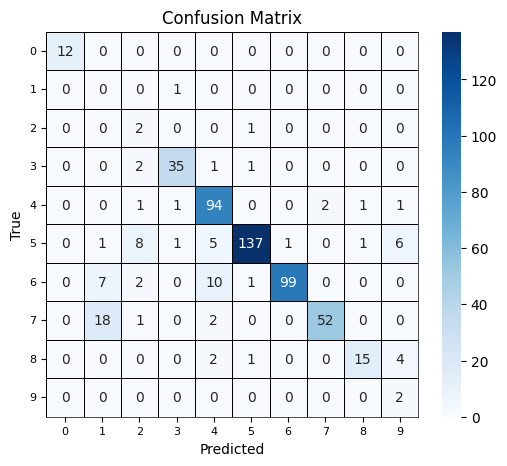

In [68]:
test_loss, test_acc, test_cm = resnet.evaluate(val_loader, detailed=True)
visualize_eval(test_loss, test_acc, test_cm)

In [64]:
checkpoint = {
    "model_state": resnet.state_dict(),
    "optimizer_state": resnet.optimizer.state_dict(),
    # "scheduler_state": scheduler.state_dict(),
    "epoch": 3,  # or current epoch
    "model_class": "RESNET18",
    "num_classes": 10,
    "architecture": str(resnet),
    "train_loss": hist_syn["train_loss"],
    "train_acc": hist_syn["train_acc"],
    "val_loss": hist_syn["val_loss"],
    "val_acc": hist_syn["val_acc"],
    "test_loss": test_loss,
    "test_acc": test_acc,
    "description": "ResNet18 fine tuned on synthetic dataset, using AdamW optimizer with lr=1e-4 and weight decay=1e-2."
}

scratch_train_path = os.path.join(weights_path, resnet_version)
os.makedirs(scratch_train_path, exist_ok=True)
torch.save(checkpoint, os.path.join(scratch_train_path, "resnet_syn_pretrained_v1.pth"))

In [87]:
cp_syn = torch.load(os.path.join(os.path.join(weights_path, resnet_version), "resnet_syn_pretrained_v1.pth"))
resnet.load_state_dict(cp_syn["model_state"])
resnet.optimizer.load_state_dict(cp_syn["optimizer_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_19384\2153394561.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, res

In [88]:
resnet.optimizer = torch.optim.AdamW(resnet.parameters(), lr=5e-5, weight_decay=1e-2)
# scheduler_mix = torch.optim.lr_scheduler.CosineAnnealingLR(
#     resnet.optimizer, T_max=5, eta_min=1e-6
# )
hist_mix = resnet.train_loop(mix_loader, val_loader, epochs=5)

Epoch 1/5: 100%|██████████| 45/45 [00:05<00:00,  8.76it/s, loss=0.0383] 


Train Loss: 0.1626 | Train Acc: 95.35% | Val Loss: 0.1737 | Val Acc: 94.54%



Epoch 2/5: 100%|██████████| 45/45 [00:04<00:00,  9.50it/s, loss=0.00537]


Train Loss: 0.0720 | Train Acc: 97.82% | Val Loss: 0.1105 | Val Acc: 96.80%



Epoch 3/5: 100%|██████████| 45/45 [00:04<00:00,  9.35it/s, loss=0.00765]


Train Loss: 0.0428 | Train Acc: 99.01% | Val Loss: 0.1186 | Val Acc: 96.61%



Epoch 4/5: 100%|██████████| 45/45 [00:04<00:00,  9.32it/s, loss=0.0144] 


Train Loss: 0.0300 | Train Acc: 98.87% | Val Loss: 0.0996 | Val Acc: 97.18%



Epoch 5/5: 100%|██████████| 45/45 [00:04<00:00,  9.50it/s, loss=0.0482] 


Train Loss: 0.0156 | Train Acc: 99.79% | Val Loss: 0.0898 | Val Acc: 97.55%



Test Loss: 0.0898, Test Accuracy: 0.9755


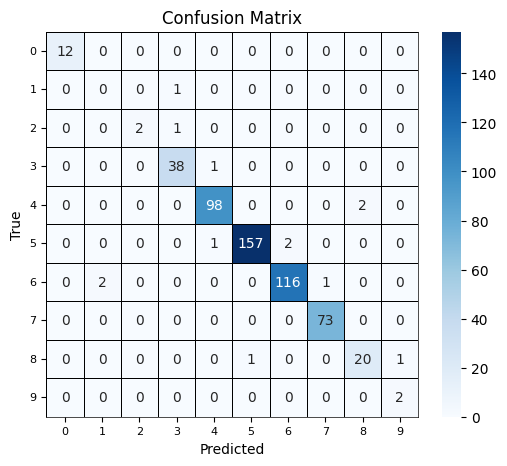

In [90]:
test_loss, test_acc, preds, test_cm = resnet.evaluate(val_loader, return_pred=True, detailed=True)
visualize_eval(test_loss, test_acc, test_cm)

In [93]:
checkpoint = {
    "model_state": resnet.state_dict(),
    "optimizer_state": resnet.optimizer.state_dict(),
    "epoch": 5,
    "model_class": "RESNET18",
    "num_classes": 10,
    "architecture": str(resnet),
    "train_loss": hist_mix["train_loss"],
    "train_acc": hist_mix["train_acc"],
    "val_loss": hist_mix["val_loss"],
    "val_acc": hist_mix["val_acc"],
    "test_loss": test_loss,
    "test_acc": test_acc,
    "description": "ResNet18 fine tuned on mixed dataset on top of resnet_syn_pretrained_v1.pth, using reinitialized AdamW optimizer with lr=5e-5 and weight decay=1e-2."
}

torch.save(checkpoint, os.path.join(weights_path, resnet_version, "resnet_mix_pretrained_v2.pth"))

In [104]:
cp_syn = torch.load(os.path.join(os.path.join(weights_path, resnet_version), "resnet_mix_pretrained_v2.pth"))
resnet.load_state_dict(cp_syn["model_state"])
resnet.optimizer.load_state_dict(cp_syn["optimizer_state"])

C:\Users\PC\AppData\Local\Temp\ipykernel_19384\2171025989.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cp_syn = torch.load(os.path.join(os.path.join(weights_path, res

In [105]:
resnet.optimizer = torch.optim.AdamW(resnet.parameters(), lr=2e-5, weight_decay=1e-2)
# scheduler_fine = torch.optim.lr_scheduler.CosineAnnealingLR(
#     resnet.optimizer, T_max=8, eta_min=1e-7
# )
hist_real = resnet.train_loop(train_loader, val_loader, epochs=5)

Epoch 1/5: 100%|██████████| 32/32 [00:03<00:00,  8.73it/s, loss=0.256]  


Train Loss: 0.1404 | Train Acc: 96.49% | Val Loss: 0.1055 | Val Acc: 97.18%



Epoch 2/5: 100%|██████████| 32/32 [00:03<00:00,  9.39it/s, loss=0.0362] 


Train Loss: 0.0479 | Train Acc: 99.00% | Val Loss: 0.0899 | Val Acc: 97.55%



Epoch 3/5: 100%|██████████| 32/32 [00:03<00:00,  9.39it/s, loss=1.32]   


Train Loss: 0.0666 | Train Acc: 99.30% | Val Loss: 0.0818 | Val Acc: 97.93%



Epoch 4/5: 100%|██████████| 32/32 [00:03<00:00,  9.39it/s, loss=0.0242] 


Train Loss: 0.0359 | Train Acc: 99.20% | Val Loss: 0.0769 | Val Acc: 98.12%



Epoch 5/5: 100%|██████████| 32/32 [00:03<00:00,  9.34it/s, loss=0.0125] 


Train Loss: 0.0285 | Train Acc: 99.10% | Val Loss: 0.0784 | Val Acc: 98.12%



Test Loss: 0.0784, Test Accuracy: 0.9812


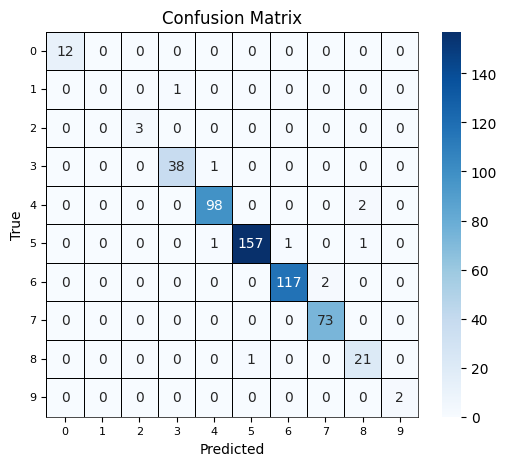

In [106]:
test_loss, test_acc, test_cm = resnet.evaluate(val_loader, detailed=True)
visualize_eval(test_loss, test_acc, test_cm)

In [ ]:
checkpoint = {
    "model_state": resnet.state_dict(),
    "optimizer_state": resnet.optimizer.state_dict(),
    "epoch": 5,
    "model_class": "RESNET18",
    "num_classes": 10,
    "architecture": str(resnet),
    "train_loss": hist_real["train_loss"],
    "train_acc": hist_real["train_acc"],
    "val_loss": hist_real["val_loss"],
    "val_acc": hist_real["val_acc"],
    "test_loss": test_loss,
    "test_acc": test_acc,
    "description": "ResNet18 fine tuned on mixed dataset on top of resnet_mix_pretrained_v2.pth, using reinitialized AdamW optimizer with lr=2e-5 and weight decay=1e-2."
}

torch.save(checkpoint, os.path.join(weights_path, resnet_version, "resnet_real_train_v1.pth"))